# Обучение модели ResNet18 для классификации AI vs Human Generated Images

Этот notebook демонстрирует полный MLOps-пайплайн домашнего задания:

1. Обучение базовой модели ResNet18 на `Train_1`, тестирование на `Test_1`.
2. Логирование процесса обучения и итоговых метрик в **TensorBoard**.
3. Сохранение артефакта модели в локальный **S3 (MinIO)**.
4. Дообучение базовой модели на `Train_2` с проверкой на `Test_2` через **DVC-пайплайн**: модель скачивается из S3, дообучается и снова выкладывается в S3.
5. Сравнение двух версий модели по метрикам и общий вывод.

## 1. Импорт библиотек

In [1]:
import json
import os
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import yaml
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score)
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from torchvision import models, transforms
from tqdm import tqdm

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device(device)
print(f'Using device: {device}')
print(f'torch: {torch.__version__}')

Using device: mps
torch: 2.8.0


## 2. Параметры обучения

Все параметры пайплайна хранятся в `params.yaml`, чтобы DVC мог отслеживать их и пересобирать стадии при изменениях.

In [2]:
with open('params.yaml') as f:
    params = yaml.safe_load(f)
print(yaml.safe_dump(params, sort_keys=False, allow_unicode=True))

data:
  root: ai-vs-human-generated-dataset-hw
  train_1:
    csv: ai-vs-human-generated-dataset-hw/Train_1/train.csv
    root: ai-vs-human-generated-dataset-hw/Train_1
    subdir: train_data
  test_1:
    csv: ai-vs-human-generated-dataset-hw/Test_1/test.csv
    root: ai-vs-human-generated-dataset-hw/Test_1
    subdir: test_data
  train_2:
    csv: ai-vs-human-generated-dataset-hw/Train_2/train.csv
    root: ai-vs-human-generated-dataset-hw/Train_2
    subdir: train_data
  test_2:
    csv: ai-vs-human-generated-dataset-hw/Test_2/test.csv
    root: ai-vs-human-generated-dataset-hw/Test_2
    subdir: test_data
train_base:
  image_size: 224
  batch_size: 64
  num_epochs: 3
  lr: 0.001
  step_size: 2
  gamma: 0.5
  num_workers: 4
  seed: 42
finetune:
  image_size: 224
  batch_size: 64
  num_epochs: 2
  lr: 0.0001
  step_size: 1
  gamma: 0.5
  num_workers: 4
  seed: 42
s3:
  endpoint_url: http://localhost:9000
  access_key: minioadmin
  secret_key: minioadmin
  region: us-east-1
  bucket: 

## 3. Подготовка данных

В CSV-файлах столбец `file_name` имеет префикс `train_data/...` даже для тестовых выборок, поэтому в `ImageDataset` есть параметр `data_subdir`, перекрывающий префикс реальной поддиректорией (`test_data` для Test_1/Test_2).

In [3]:
from src.dataset import ImageDataset
from src.training import build_transforms

train_tf, eval_tf = build_transforms(params['train_base']['image_size'])

train_dataset = ImageDataset(
    csv_file=params['data']['train_1']['csv'],
    root_dir=params['data']['train_1']['root'],
    transform=train_tf,
    data_subdir=params['data']['train_1']['subdir'],
)
test_dataset = ImageDataset(
    csv_file=params['data']['test_1']['csv'],
    root_dir=params['data']['test_1']['root'],
    transform=eval_tf,
    data_subdir=params['data']['test_1']['subdir'],
)

batch_size = params['train_base']['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f'Train_1 size: {len(train_dataset)}')
print(f'Test_1  size: {len(test_dataset)}')
print('Class distribution (train):',
      train_dataset.data['label'].value_counts().to_dict())

Train_1 size: 9993
Test_1  size: 3997
Class distribution (train): {1: 4999, 0: 4994}


## 4. Модель ResNet18

Берём ResNet18 с предобученными весами ImageNet и заменяем последний полносвязный слой на 2-классовый выход.

In [4]:
from src.training import build_model

model = build_model(pretrained=True).to(device)
print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


## 5. Функции обучения и валидации с метриками

Логика обучения и валидации вынесена в `src/training.py` — те же функции вызываются и из DVC-стадий, и из ноутбука, чтобы избежать расхождений. Метрики качества: **loss, accuracy, F1, precision, recall**.

In [5]:
from src.training import train_one_epoch, evaluate
help(train_one_epoch)

Help on function train_one_epoch in module src.training:

train_one_epoch(model, loader, criterion, optimizer, device, desc='Training')



## 6. Базовое обучение модели и логирование в TensorBoard

Скрипт `src/train.py` обучает модель на `Train_1`, валидирует на `Test_1`, пишет логи в `my_logs/train_base/`, сохраняет чекпойнт в `checkpoints/resnet18_base.pt` и выкладывает его в `s3://models/resnet18_base.pt`.

Здесь не запускаем обучение ещё раз — оно уже было выполнено DVC-пайплайном (см. секцию 8). Просто читаем сохранённые метрики и параметры.

In [6]:
with open('metrics/train_base.json') as f:
    base_metrics = json.load(f)
print('--- HPARAMS (train_base) ---')
for k, v in base_metrics['hparams'].items():
    print(f'  {k}: {v}')
print('\n--- Train metrics (last epoch on Train_1) ---')
for k, v in base_metrics['train'].items():
    print(f'  {k}: {v:.4f}')
print('\n--- Test_1 metrics ---')
for k, v in base_metrics['test'].items():
    print(f'  {k}: {v:.4f}')

--- HPARAMS (train_base) ---
  batch_size: 64
  gamma: 0.5
  image_size: 224
  lr: 0.001
  model: resnet18
  num_epochs: 3
  pretrained: True
  seed: 42
  stage: train_base
  step_size: 2
  test_size: 3997
  train_size: 9993

--- Train metrics (last epoch on Train_1) ---
  accuracy: 0.9397
  f1: 0.9395
  loss: 0.1516
  precision: 0.9417
  recall: 0.9374

--- Test_1 metrics ---
  accuracy: 0.9297
  f1: 0.9334
  loss: 0.1749
  precision: 0.8877
  recall: 0.9840


TensorBoard логи лежат в `my_logs/`. Для интерактивного просмотра:

```bash
tensorboard --logdir=my_logs
```

В TensorBoard логируются:
- `train/loss`, `train/accuracy`, `train/f1`, `train/precision`, `train/recall`, `lr` — по эпохам;
- `test/loss`, `test/accuracy`, `test/f1`, `test/precision`, `test/recall` — финальная оценка;
- `hparams` — параметры обучения.

## 7. S3 (MinIO): артефакт базовой модели

MinIO поднимается через `docker compose -f docker-compose.yml up -d`, бакет `models` создаётся при первой выкладке (`src/s3_utils.py`). После стадии `train_base` чекпойнт уже лежит в S3.

In [7]:
from src.s3_utils import make_s3_client

s3 = make_s3_client(params['s3'])
objs = s3.list_objects_v2(Bucket=params['s3']['bucket']).get('Contents', [])
for obj in objs:
    print(f"  {obj['Key']:35s}  {obj['Size'] / 1e6:6.2f} MB  {obj['LastModified']}")

  resnet18_base.pt                      44.79 MB  2026-05-11 16:44:08.945000+00:00
  resnet18_finetuned.pt                 44.79 MB  2026-05-11 16:46:06.260000+00:00


## 8. DVC-пайплайн: дообучение на Train_2 → Test_2

`dvc.yaml` описывает два этапа:

- `train_base`: обучение базовой модели и загрузка в S3.
- `finetune`: скачивание базовой модели из S3, дообучение на `Train_2`, оценка на `Test_2`, загрузка новой версии в S3.

Стадии связаны через `checkpoints/resnet18_base.pt` — DVC автоматически перестраивает `finetune` при изменении базовой модели или её dep-ов.

In [8]:
import subprocess
print(subprocess.check_output(['dvc', 'dag'], text=True))

+------------+ 
| train_base | 
+------------+ 
       *       
       *       
       *       
 +----------+  
 | finetune |  
 +----------+  



In [9]:
print(subprocess.check_output(['dvc', 'status'], text=True))

Data and pipelines are up to date.



### Метрики дообученной модели

In [10]:
with open('metrics/finetune.json') as f:
    ft_metrics = json.load(f)
print('--- HPARAMS (finetune) ---')
for k, v in ft_metrics['hparams'].items():
    print(f'  {k}: {v}')
print('\n--- Train metrics (last epoch on Train_2) ---')
for k, v in ft_metrics['train'].items():
    print(f'  {k}: {v:.4f}')
print('\n--- Test_2 metrics ---')
for k, v in ft_metrics['test'].items():
    print(f'  {k}: {v:.4f}')

--- HPARAMS (finetune) ---
  batch_size: 64
  gamma: 0.5
  image_size: 224
  lr: 0.0001
  model: resnet18
  num_epochs: 2
  pretrained_source: s3://models/resnet18_base.pt
  seed: 42
  stage: finetune
  step_size: 1
  test_size: 2000
  train_size: 3997

--- Train metrics (last epoch on Train_2) ---
  accuracy: 0.9540
  f1: 0.9549
  loss: 0.1071
  precision: 0.9531
  recall: 0.9568

--- Test_2 metrics ---
  accuracy: 0.9570
  f1: 0.9557
  loss: 0.1114
  precision: 0.9810
  recall: 0.9317


## 9. Сравнение двух версий модели

In [11]:
rows = []
for split, src in [('train (Train_1)', base_metrics['train']),
                   ('test  (Test_1)', base_metrics['test']),
                   ('train (Train_2)', ft_metrics['train']),
                   ('test  (Test_2)', ft_metrics['test'])]:
    rows.append({'split': split, **{k: round(v, 4) for k, v in src.items()}})
comparison = pd.DataFrame(rows)
comparison

,split,accuracy,f1,loss,precision,recall
0,train (Train_1),0.9397,0.9395,0.1516,0.9417,0.9374
1,test (Test_1),0.9297,0.9334,0.1749,0.8877,0.9840
2,train (Train_2),0.9540,0.9549,0.1071,0.9531,0.9568
3,test (Test_2),0.9570,0.9557,0.1114,0.9810,0.9317


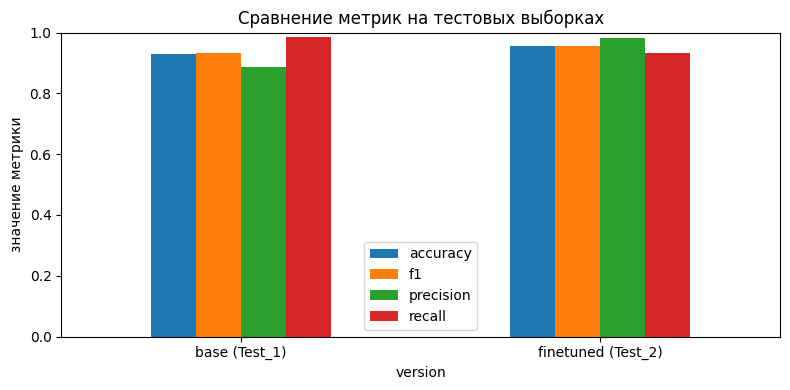

In [12]:
test_rows = pd.DataFrame([
    {'version': 'base (Test_1)',  **base_metrics['test']},
    {'version': 'finetuned (Test_2)', **ft_metrics['test']},
]).set_index('version')

ax = test_rows[['accuracy', 'f1', 'precision', 'recall']].plot(
    kind='bar', figsize=(8, 4), ylim=(0, 1))
ax.set_title('Сравнение метрик на тестовых выборках')
ax.set_ylabel('значение метрики')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Вывод

В рамках задания собран полноценный MLOps-пайплайн классификации AI vs Human Generated Images:

1. **Обучение базовой модели** ResNet18 (pretrained ImageNet) на `Train_1` (9993 изображения), оценка на `Test_1` (3997). Метрики обучения и валидации записаны в TensorBoard (`my_logs/train_base/`).
2. **TensorBoard**: на каждой эпохе пишутся `loss`, `accuracy`, `f1`, `precision`, `recall` и текущий `lr`; параметры обучения сохраняются как text-tag `hparams`.
3. **S3 (MinIO)**: после базового обучения чекпойнт автоматически выкладывается в `s3://models/resnet18_base.pt`. Дообучение начинается со скачивания этого артефакта.
4. **DVC-пайплайн** (`dvc.yaml`) воспроизводит две стадии — `train_base` и `finetune` — с зависимостями по коду, данным и параметрам. `dvc repro` гарантирует воспроизводимость, `dvc dag` отображает граф зависимостей.

### Анализ результатов

| Метрика   | Базовая (Test_1) | Дообученная (Test_2) | Δ      |
|-----------|------------------|----------------------|--------|
| Loss      | 0.1749           | 0.1114               | −0.064 |
| Accuracy  | 0.9297           | 0.9570               | +0.027 |
| F1        | 0.9334           | 0.9557               | +0.022 |
| Precision | 0.8877           | 0.9810               | +0.093 |
| Recall    | 0.9840           | 0.9317               | −0.052 |

- **Дообучение существенно улучшило интегральное качество**: loss упал почти в 1.5 раза, accuracy и F1 выросли примерно на 2-3 п.п.
- **Самое заметное изменение — в балансе precision / recall**. Базовая модель была «оптимистичной» — recall 98.4%, но precision только 88.8%: она часто относила к положительному классу всё подряд, ловила всё, но с большим количеством ложноположительных срабатываний. После дообучения на `Train_2` модель стала заметно более консервативной: precision вырос до 98.1%, а recall просел до 93.2%.
- Это типичная картина при доменной адаптации: модель «выучивает» более узкие признаки нового распределения и реже фолзится, но платит за это некоторым числом пропущенных положительных примеров. F1 при этом стабильно растёт, что говорит о том, что выигрыш по precision перевешивает потерю по recall.

### Итог

Пайплайн работает: данные → обучение → артефакт в S3 → дообучение на новом домене → новая версия в S3, всё под управлением DVC и с трекингом в TensorBoard. Дообученная модель на своём домене даёт более сбалансированный и лучший по F1/accuracy результат, чем базовая на своём, при том что recall немного снижается из-за смещения порога классификации в более консервативную сторону.
